In [1]:
atomstring = '''
Fe -0.64147387529051 0.51990405379180 0.11450483185168
O 0.33915564253394 2.18819453520299 -0.84159903476570
H 0.65823736209818 2.99799985286513 -0.40575899522591
O -1.29914529040912 -0.20924466129350 -1.80322550106302
H -2.11419692217693 0.03267722517314 -2.27701147100162
O 0.01237770373627 1.24396717111997 2.03533113813669
H 0.83097217272839 1.00756306178418 2.50577204385612
O -1.62284672685044 -1.15048542622041 1.07007991103536
H -1.94592790838151 -1.95766677806096 0.63237073377438
O -2.41866907277644 1.66373032346654 0.25658821238371
H -2.55381601393967 2.56024091790599 -0.09930153080408
O 1.13404022498401 -0.62623224778001 -0.02436092147139
H 1.26370551457750 -1.52400168391753 0.33034524187694
H -3.28110369794222 1.35873477131317 0.59094893393907
H -0.81032015579443 -0.82248643308581 -2.37966496653734
H 1.99795010138314 -0.32692539271158 -0.36001715946551
H 0.57998322602479 2.26642229799559 -1.78148703231078
H -0.47668197075682 1.85673194452426 2.61208351578631
H -1.85653031374812 -1.23356353207299 2.011352050005
'''

In [57]:
import re

# plain all-electron Dunning cc-pVXZ, incl. aug- and core-valence variants;
# anchored $ so relativistic/PP suffixes (-dk, -pp, -f12) deliberately fail
_CCPVXZ = re.compile(r'^(daug|aug)?ccp(w?c)?v[dtq56]z$')

def _is_ccpvxz_family(basis):
    """True only if EVERY element uses a cc-pVXZ-family basis name."""
    def is_cc(name):
        if not isinstance(name, str):     # parsed/custom basis object -> not cc-pVXZ
            return False
        return bool(_CCPVXZ.match(re.sub(r'[\s\-_]', '', name.lower())))
    if isinstance(basis, str):
        return is_cc(basis)
    if isinstance(basis, dict):
        return bool(basis) and all(is_cc(v) for v in basis.values())
    return False

In [58]:
import numpy as np
from pyscf import gto, scf, mp, cc

mol = gto.M(atom = atomstring,
            basis = {
                'default': 'cc-pvdz',
                'Fe': 'cc-pvtz'
                },
            verbose = 4,
            unit = 'angstrom',
            symmetry = 0,
            charge = 2,
            spin = 4,
            max_memory = 20000,
            )

_is_ccpvxz_family(mol.basis)


System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-28-generic', version='#28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sun Aug 16 18:31:26 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 19
[INPUT] num. electrons = 84
[INPUT] charge = 2
[INPUT] spin (= nelec alpha-beta = 2S) = 4
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z  

True

In [ ]:
mf = scf.UHF(mol).density_fit()
mf = mf.x2c()
dm0 = mf.from_chk('./hs_tdz_mf.chk')
# mf.init_guess = 'chk'
mf.max_cycle = 100
mf.level_shift = 0.5
mf = mf.newton()
mf.kernel(dm0=dm0)

# stable = False
# for i in range(10):
#     print(f'mf stability test {i+1}')
#     if not stable:
#         mo_i, _, stable,_ = mf.stability(return_status=True)
#         dm = mf.make_rdm1(mo_i,mf.mo_occ)
#         mf = mf.newton()
#         mf.kernel(dm0=dm)
#     elif stable:
#         print(f'mf energy: {mf.e_tot}, stability {stable}')
#         break

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-28-generic', version='#28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sun Aug 16 18:29:54 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 19
[INPUT] num. electrons = 84
[INPUT] charge = 2
[INPUT] spin (= nelec alpha-beta = 2S) = 4
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z  

np.float64(-1727.542864590526)

In [3]:
mymp = mp.MP2(mf).set_frozen()
mymp.kernel()
print(mymp.e_corr)


******** <class 'pyscf.mp.dfump2.DFUMP2'> ********
nocc = (np.int64(33), np.int64(29)), nmo = (235, 235)
frozen orbitals 11
max_memory 20000 MB (current use 704 MB)
E(DFUMP2) = -1729.38153669198  E_corr = -1.83772509936822
E(SCS-DFUMP2) = -1729.29866110431  E_corr = -1.75484951169567
E_corr(same-spin) = -0.519716085630219
E_corr(oppo-spin) = -1.318009013738
-1.8377250993682186


In [22]:
from pyscf.scf import atom_hf

def free_atom_ref(mol, occ_tol=1e-6):
    """Reference funcs = free-atom occupied HF orbitals, in the working basis.
       Returns C_ref (nao, n_ref), atom-block-diagonal."""
    atm_scf = atom_hf.get_atm_nrhf(mol)          # spherically-averaged atomic HF
    aoslice = mol.aoslice_by_atom()
    nao, cols = mol.nao, []
    for ia in range(mol.natm):
        symb = mol.atom_symbol(ia)
        if symb not in atm_scf:
            symb = mol.atom_pure_symbol(ia)
        e_hf, e, c, occ = atm_scf[symb]
        c_at = c[:, occ > occ_tol]               # core + (fractionally) occupied valence
        p0, p1 = aoslice[ia, 2], aoslice[ia, 3]
        block = np.zeros((nao, c_at.shape[1]))
        block[p0:p1] = c_at
        cols.append(block)
    return np.hstack(cols)

import numpy as np
from collections import defaultdict
from pyscf import gto
from pyscf.lo import iao, orth

def free_atom_minao(mol, occ_tol=1e-6, sv_tol=1e-8):
    """Free-atom occupied HF orbitals (core+valence) in the uncontracted
    working basis, packaged as a PySCF basis dict for use as `minao`."""
    elems = set(mol.elements)

    # uncontracted working basis, per element
    unc = {sym: gto.uncontract(mol._basis[sym]) for sym in elems}

    # spherically-averaged atomic HF in that uncontracted basis
    pmol = mol.copy()
    pmol.build(False, False, basis=unc)
    atm_scf = atom_hf.get_atm_nrhf(pmol)          # {sym: (e_hf, e, c, occ)}

    ref_basis = {}
    for sym in elems:
        # single-atom mol only to read the (l, exponent) shell layout
        a1 = gto.M(atom=f'{sym} 0 0 0', basis={sym: unc[sym]},
                   spin=gto.charge(sym) % 2, verbose=0)
        ao_loc = a1.ao_loc_nr()
        shells_by_l = defaultdict(list)           # l -> [(exp, ao_start), ...]
        for ib in range(a1.nbas):
            shells_by_l[a1.bas_angular(ib)].append(
                (float(a1.bas_exp(ib)[0]), ao_loc[ib]))

        _, _, c, occ = atm_scf[sym]
        assert c.shape[0] == a1.nao
        occ_cols = c[:, occ > occ_tol]            # occupied core + valence

        shells = []
        for l in sorted(shells_by_l):
            exps   = np.array([e for e, _ in shells_by_l[l]])
            starts = [s for _, s in shells_by_l[l]]
            p, ncomp = len(exps), 2 * l + 1
            # radial coeffs over exponents, all m-components stacked
            A = np.stack([occ_cols[s:s+ncomp, :] for s in starts])  # (p, ncomp, nocc)
            Rrad = A.reshape(p, -1)                                   # (p, ncomp*nocc)
            u, sv, _ = np.linalg.svd(Rrad, full_matrices=False)
            for i in np.where(sv > sv_tol * sv.max())[0]:            # distinct radial fns
                d = u[:, i]
                shells.append([l] + [[float(exps[k]), float(d[k])] for k in range(p)])
        ref_basis[sym] = shells
    return ref_basis

In [5]:
atm_scf = atom_hf.get_atm_nrhf(mol) 

Spherically averaged atomic HF for {'Fe', 'H', 'O'}


******** <class 'pyscf.scf.atom_hf.AtomSphAverageRHF'> ********
method = AtomSphAverageRHF
initial guess = minao
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 50
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmp0b4lbcfk
max_memory 20000 MB (current use 1672 MB)
atom = Fe
Set gradient conv threshold to 3.16228e-05
Initial guess from minao.
init E= -1256.92251596845
cycle= 1 E= -1252.13381271179  delta_E= 4.79  |g|=    0  |ddm|= 7.94
cycle= 2 E= -1251.22556759069  delta_E= 0.908  |g|=    0  |ddm|= 12.1
cycle= 3 E= -1256.68822008678  delta_E= -5.46  |g|=    0  |ddm|= 9.89
cycle= 4 E= -1257.65263478333  delta_E= -0.964  |g|=    0  |ddm|= 1.57
cycle= 5 E= -1257.65829401371  delta_E= -0.00566  |g|=    0  |ddm|= 0.489
cycle= 6 E= -1257.65927111651  delta_E= -0.000977

In [23]:
ref_basis = free_atom_minao(mol, occ_tol=1e-6, sv_tol=1e-8)

Spherically averaged atomic HF for {'Fe', 'H', 'O'}


******** <class 'pyscf.scf.atom_hf.AtomSphAverageRHF'> ********
method = AtomSphAverageRHF
initial guess = minao
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 50
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmpukf8a2ti
max_memory 20000 MB (current use 1711 MB)
atom = Fe
Set gradient conv threshold to 3.16228e-05
Initial guess from minao.
init E= -1256.92456910641
cycle= 1 E= -1255.99896402579  delta_E= 0.926  |g|=    0  |ddm|= 25.2
cycle= 2 E= -1255.09761857463  delta_E= 0.901  |g|=    0  |ddm|= 23.3
cycle= 3 E= -1260.61453893918  delta_E= -5.52  |g|=    0  |ddm|=  3.4
cycle= 4 E= -1261.57170867645  delta_E= -0.957  |g|=    0  |ddm|= 1.27
cycle= 5 E= -1261.5755539638  delta_E= -0.00385  |g|=    0  |ddm|= 0.318
cycle= 6 E= -1261.57670160295  delta_E= -0.00115 

In [24]:
ref_basis

{'Fe': [[0,
   [4316265.0, -2.7694977164595934e-06],
   [646342.4, -2.153737256134572e-05],
   [147089.7, -0.00011325280169988707],
   [41661.52, -0.0004780888907891581],
   [13590.77, -0.001735737505529709],
   [4905.75, -0.005607429131359599],
   [1912.746, -0.016279942142100674],
   [792.6043, -0.042069966620095926],
   [344.8065, -0.09289389439449043],
   [155.8999, -0.16131583763210547],
   [72.23091, -0.17238027235924852],
   [32.72506, 0.027302693303643304],
   [15.66762, 0.46066180197229195],
   [7.503483, 0.5663730638318727],
   [4.6844, -0.0013852757750345175],
   [3.312223, -0.04675504869597262],
   [1.558471, -0.5494223115553959],
   [1.2204, 0.03458532288818889],
   [0.683914, -0.30688600412977435],
   [0.146757, -0.01804846609406363],
   [0.070583, 0.008449964383959717],
   [0.031449, -0.00224202654635017]],
  [0,
   [4316265.0, 9.394367585458242e-06],
   [646342.4, 7.304193619568164e-05],
   [147089.7, 0.00038409066566670027],
   [41661.52, 0.0016198657646180707],
   [13

In [28]:
from pyscf.data import elements
from pyscf.data import elements
from pyscf.lno import lnoccsd, ulnoccsd, tools
from pyscf.lno.tools import autofrag_iao
from pyscf import lo
from afqmc.lno_afqmc import tools as lnoafqmc_tools

In [31]:
s1e = mf.get_ovlp()
nfrozen = elements.chemcore(mol)
nocca = np.count_nonzero(mf.mo_occ[0])
orbocc = mf.mo_coeff[0][:,nfrozen:nocca]
iao_coeff0 = iao.iao(mol, orbocc, minao='minao')
iao_coeff0 = lo.orth.vec_lowdin(iao_coeff0, s1e)

In [32]:
iao_coeff1 = iao.iao(mol, orbocc, minao=ref_basis)
iao_coeff1 = lo.orth.vec_lowdin(iao_coeff1, s1e)

In [35]:
lnoafqmc_tools.mo_span(iao_coeff1, s1e, orbocc)

(np.float64(1.9062529332813938e-13), np.float64(0.952586014024825))

In [8]:
def name_fragments(frag_atmlist, elements, sep=""):
    """
    Build a name for each fragment by tagging every atom with its
    element symbol and its original index.

    frag_atmlist : list of lists of atom indices
    elements     : list mapping atom index -> element symbol
    sep          : string placed between atoms in a fragment name
    """
    return [sep.join(f"{elements[i]}{i}" for i in frag)
            for frag in frag_atmlist]

In [ ]:
from pyscf import lo

def riao_fragment(mf, nfrozen, frag_type='atom', more_loc=None, minao='minao'):
    # IAO localization
    mol = mf.mol
    s1e = mf.get_ovlp()
    moliao = lo.iao.reference_mol(mol, minao)
    nocc = np.count_nonzero(mf.mo_occ)
    orbocc = mf.mo_coeff[:,nfrozen:nocc]
    lo_coeff = lo.iao.iao(mol, orbocc, minao=minao)
    lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)

    if frag_type == 'atom':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=False)
    elif frag_type == 'h2heavy':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=True)
    else:
        raise ValueError(f'Unsupported fragment type {str(frag_type)}')

    if more_loc is None:
        frag_list = autofrag_iao(moliao, 'atom', frag_atmlist)
    elif more_loc == 'boys':
        lo_coeff = lo.Boys(mol).kernel(lo_coeff)
        lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    elif more_loc == 'pm':
        lo_coeff = lo.PM(mol).kernel(lo_coeff)
        lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    else:
        raise ValueError(f'Unsupported lo type {str(more_loc)}')

    frag_name = name_fragments(frag_atmlist, moliao.elements, sep="")

    ortho = lo_coeff.conj().T @ s1e @ lo_coeff
    assert np.allclose(ortho, np.eye(ortho.shape[1]), atol=1e-8), \
        f"IAOs not orthonormal: max dev {np.abs(ortho - np.eye(ortho.shape[1])).max():.2e}"
    
    return lo_coeff, frag_list, frag_name

def uiao_fragment(mf, nfrozen, frag_type='atom', more_loc=None, minao='minao'):
    # IAO localization
    mol = mf.mol
    s1e = mf.get_ovlp()
    moliao = lo.iao.reference_mol(mol, minao)
    nocca = np.count_nonzero(mf.mo_occ[0])
    noccb = np.count_nonzero(mf.mo_occ[1])
    orbocc_a = mf.mo_coeff[0][:,nfrozen:nocca]
    orbocc_b = mf.mo_coeff[1][:,nfrozen:noccb]
    lo_coeff_a = lo.iao.iao(mol, orbocc_a, minao)
    lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, s1e)
    lo_coeff_b = lo.iao.iao(mol, orbocc_b, minao)
    lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, s1e)

    if frag_type == 'atom':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=False)
    elif frag_type == 'h2heavy':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=True)
    else:
        raise ValueError(f'Unsupported fragment type {str(frag_type)}')

    if more_loc is None:
        lo_coeff = [lo_coeff_a, lo_coeff_b]
        frag_list = autofrag_iao(moliao, 'atom', frag_atmlist)
        frag_list = [[i,i] for i in frag_list]
    elif more_loc == 'boys':
        lo_coeff_a = lo.Boys(mol).kernel(lo_coeff_a)
        lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, s1e)
        lo_coeff_b = lo.Boys(mol).kernel(lo_coeff_b)
        lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, s1e)
        lo_coeff = [lo_coeff_a, lo_coeff_b]
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    elif more_loc == 'pm':
        lo_coeff_a = lo.PM(mol).kernel(lo_coeff_a)
        lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, s1e)
        lo_coeff_b = lo.PM(mol).kernel(lo_coeff_b)
        lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, s1e)
        lo_coeff = [lo_coeff_a, lo_coeff_b]
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    else:
        raise TypeError(f'Unsupported lo type {str(more_loc)}')

    frag_name = name_fragments(frag_atmlist, moliao.elements, sep="")

    ortho_a = lo_coeff[0].conj().T @ s1e @ lo_coeff[0]
    ortho_b = lo_coeff[1].conj().T @ s1e @ lo_coeff[1]
    assert np.allclose(ortho_a, np.eye(ortho_a.shape[1]), atol=1e-8), \
        f"IAOs not orthonormal: max dev {np.abs(ortho_a - np.eye(ortho_a.shape[1])).max():.2e}"
    assert np.allclose(ortho_b, np.eye(ortho_b.shape[1]), atol=1e-8), \
        f"IAOs not orthonormal: max dev {np.abs(ortho_b - np.eye(ortho_b.shape[1])).max():.2e}"

    return lo_coeff, frag_list, frag_name

def iao_fragment(mf, nfrozen=None, frag_type='atom', more_loc=None, minao='minao'):
    mol = mf.mol

    if nfrozen is None:
        nfrozen = elements.chemcore(mol)

    if not _is_ccpvxz_family(mol.basis):
        print('Detected basis set not in the cc-pVXZ family. '
              'Run free atom scf to generate reference basis.')
        minao = free_atom_minao(mol, occ_tol=1e-6, sv_tol=1e-8)

    if isinstance(mf, scf.rhf.RHF):
        return riao_fragment(mf, nfrozen, frag_type, more_loc, minao)
    elif isinstance(mf, scf.uhf.UHF):
        return uiao_fragment(mf, nfrozen, frag_type, more_loc, minao)
    else:
        raise TypeError(f'Unsupported mf type {type(mf)}')

In [42]:
from afqmc.lno_afqmc import lno_afqmc
import lno_tools
from jax import random

def run_lno(mf,
            lo_coeff, 
            frag_list,
            frag_name,
            nfrozen = 0,
            lno_thresh = 1e-6,
            qmc_options = {}, 
            chol_cut = 1e-5, 
            target_qmc_err = 1e-3, 
            run_frag = None, 
            run_ccsd = False,
            run_qmc = False,
            ):

    print("\n ******* LNO-CALCULATION ******* \n")

    lnoafqmc_tools.check_span(mf, lo_coeff, nfrozen, thresh=1e-10)

    if isinstance(mf, scf.rhf.RHF):
        spin_type = "restricted"
        mlno = lnoccsd.LNOCCSD(mf, lo_coeff, frag_list, frozen=nfrozen).set(verbose=mf.verbose)
    elif isinstance(mf, scf.uhf.UHF):
        spin_type = "unrestricted"
        mlno = ulnoccsd.ULNOCCSD(mf, lo_coeff, frag_list, frozen=nfrozen).set(verbose=mf.verbose)
    else:
        raise TypeError(f'unsupported mean-field type: {type(mf)}')

    if isinstance(lno_thresh, float):
        mlno.lno_thresh = [lno_thresh*10, lno_thresh]
    elif isinstance(lno_thresh, (list, tuple)):
        assert len(lno_thresh) == 2
        mlno.lno_thresh = [lno_thresh[0], lno_thresh[1]]

    lno_thresh = mlno.lno_thresh
    print(f"LNO THRESHOLD = {mlno.lno_thresh}")
    lno_type = ['1h','1h']
    eris = mlno.ao2mo()

    nfrag_tot = len(frag_list)
    if run_frag is None:
        run_frag = range(nfrag_tot)

    frag_list = [frag_list[i] for i in run_frag]
    frag_name = [frag_name[i] for i in run_frag]
    nfrag_run = len(frag_list)

    lno_pct_occ = [None, None]
    lno_norb = [[None,None]] * nfrag_tot

    las_size = [None]*nfrag_run
    lno_emp = np.zeros(nfrag_run, dtype='float64')
    lno_ecc  = np.zeros(nfrag_run, dtype='float64')
    lno_eqmc  = np.zeros(nfrag_run, dtype='float64')
    lno_eqmc_err  = np.zeros(nfrag_run, dtype='float64')


    seeds = random.randint(random.PRNGKey(qmc_options["seed"]),
                           shape=(nfrag_tot,), 
                           minval=0, 
                           maxval=100*nfrag_tot
                           )
    
    qmc_options["max_error"] = target_qmc_err / np.sqrt(nfrag_tot)

    # Loop over fragment
    for ifrag, frag_idx in enumerate(run_frag):
        
        loidx = frag_list[ifrag]

        print("\n")
        width = 80
        msg = f" {spin_type} LNO-FRAGMENT {frag_idx+1}/({nfrag_run},{nfrag_tot}) "
        print(msg.center(width, '='))
        print(f"Fragment Name {frag_name[ifrag]}")

        orbloc, lno_param \
            = lno_tools.get_lnoparam(mlno, lo_coeff, lno_thresh, lno_pct_occ, lno_norb, loidx, ifrag)

        lno_coeff, lno_frozen, uocc_loc, _ \
                    = mlno.make_las(eris, orbloc, lno_type, lno_param)
        
        if isinstance(mlno._scf, scf.rhf.RHF):
            lno_frozen, maskact \
                = lnoccsd.get_maskact(lno_frozen, mlno.mo_occ.size)
        elif isinstance(mlno._scf, scf.uhf.UHF):
            lno_frozen, maskact \
                = ulnoccsd.get_maskact(lno_frozen, [mlno.mo_occ[0].size, mlno.mo_occ[1].size])
        else:
            raise TypeError(f'unsupported mean-field type: {type(mlno._scf)}')

        _, nlno = lnoafqmc_tools.split_lno(mlno, lno_coeff, lno_frozen)

        eorb_mp = lno_tools.lnomp2_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=4)

        if run_ccsd:
            eorb_cc, t1, t2 = \
                lno_tools.lnoccsd_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=4)
        else: eorb_cc = 0.0

        if run_qmc:
            eorb_qmc, eorb_qmc_err \
                = lno_afqmc.lnoafqmc_kernel(
                    mlno, lno_coeff, uocc_loc, lno_frozen, t1, t2, 
                    chol_cut, frag_idx, seeds, qmc_options)
            
        else: eorb_qmc = 0.0; eorb_qmc_err = 0.0

        print(f'LNO-Active Space Size     {nlno}')
        print(f'LNO-MP2 Orbital Energy    {eorb_mp:.8f}')
        print(f'LNO-CCSD Orbital Energy   {eorb_cc:.8f}')
        print(fr'LNO-AFQMC Orbital Energy  {eorb_qmc:.5f} {eorb_qmc_err:.5f}')

        las_size[ifrag] = nlno
        lno_emp[ifrag] = eorb_mp
        lno_ecc[ifrag] = eorb_cc
        lno_eqmc[ifrag] = eorb_qmc
        lno_eqmc_err[ifrag] = eorb_qmc_err

        qmc_err = np.sqrt(np.sum(np.array(lno_eqmc_err)**2))

    return np.array(las_size).max(), sum(lno_emp), sum(lno_ecc), sum(lno_eqmc), qmc_err

In [43]:
options = {
           'eql_time': 10,
           'n_prop_steps': 50,
           'n_blocks': 100,
           'n_walkers': 100,
           'mix_precision': False,
           'seed': 17,
           'walker_type': 'uhf',
           'trial': 'upt2ccsd',
           }

threshs = [3e-5,1e-5,3e-6,1e-6,3e-7]

iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='h2heavy', more_loc=None, ref_basis='manual')

las1 = np.zeros(len(threshs))
elnomp1 = np.zeros(len(threshs))
elnocc1 = np.zeros(len(threshs))
elnoqmc1 = np.zeros(len(threshs))
elnoqmc_err1 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las1[i], elnomp1[i], elnocc1[i], elnoqmc1[i], elnoqmc_err1[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )

Spherically averaged atomic HF for {'Fe', 'H', 'O'}


******** <class 'pyscf.scf.atom_hf.AtomSphAverageRHF'> ********
method = AtomSphAverageRHF
initial guess = minao
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 50
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmp986lhmaw
max_memory 20000 MB (current use 1806 MB)
atom = Fe
Set gradient conv threshold to 3.16228e-05
Initial guess from minao.
init E= -1256.92456910641
cycle= 1 E= -1255.99896402579  delta_E= 0.926  |g|=    0  |ddm|= 25.2
cycle= 2 E= -1255.09761857463  delta_E= 0.901  |g|=    0  |ddm|= 23.3
cycle= 3 E= -1260.61453893918  delta_E= -5.52  |g|=    0  |ddm|=  3.4
cycle= 4 E= -1261.57170867645  delta_E= -0.957  |g|=    0  |ddm|= 1.27
cycle= 5 E= -1261.57555396379  delta_E= -0.00385  |g|=    0  |ddm|= 0.318
cycle= 6 E= -1261.57670160296  delta_E= -0.00115

[107. 142. 162. 179. 219.]
[-1.79655234 -1.82104512 -1.83159191 -1.835128   -1.83688261]


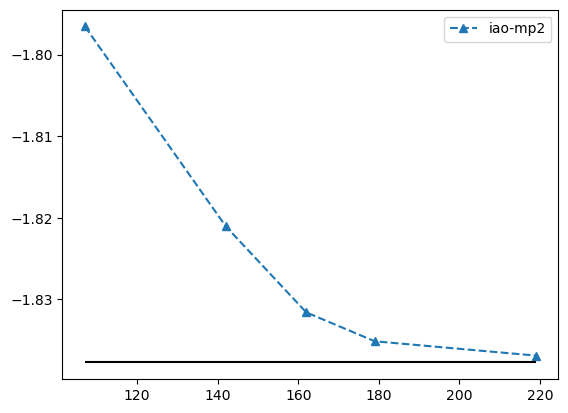

In [44]:
emp2_ref = mymp.e_corr
print(las1)
print(elnomp1)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="iao-mp2")
plt.hlines(emp2_ref, xmin=min(las1), xmax=max(las1), colors='k')
plt.legend()
plt.show()

In [45]:
iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='h2heavy', more_loc=None, ref_basis='auto')

las2 = np.zeros(len(threshs))
elnomp2 = np.zeros(len(threshs))
elnocc2 = np.zeros(len(threshs))
elnoqmc2 = np.zeros(len(threshs))
elnoqmc_err2 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las2[i], elnomp2[i], elnocc2[i], elnoqmc2[i], elnoqmc_err2[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )


 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
LNO THRESHOLD = [0.00030000000000000003, 3e-05]


====================== unrestricted LNO-FRAGMENT 1/(7,7) =======================
Fragment Name Fe0
LO occ proj: 10 active | 5 standby | 18 orthogonal
LO occ proj: 6 active | 8 standby | 15 orthogonal
nfrozen occupied orbitals:  [11, 11]
nactive occupied orbitals:  [33, 29]
nactive virtual orbitals:   [127, 117]
nfrozen virtual orbitals:   [75, 89]

WARN: CCSD detected DF being used in the HF object. MO integrals are computed based on the DF 3-index tensors.
It's recommended to use dfccsd.CCSD for the DF-CCSD calculations

Init t2, MP2 energy = -1.67818009234264
LNO-Active Space Size     [160, 146]
LNO-MP2 Orbital Energy    -0.56916102
LNO-CCSD Orbital Energy   0.00000000
LNO-AFQMC Orbital Energy  0.00000 0.00000


====================== unrestricted LNO-FRAGMENT 2/(7,7) =======================
Fragment Name O1

[107. 142. 162. 179. 219.]
[-1.79655234 -1.82104512 -1.83159191 -1.835128   -1.83688261]
[160. 182. 219. 224. 235.]
[-1.80483216 -1.82525055 -1.83349476 -1.83581797 -1.83707309]


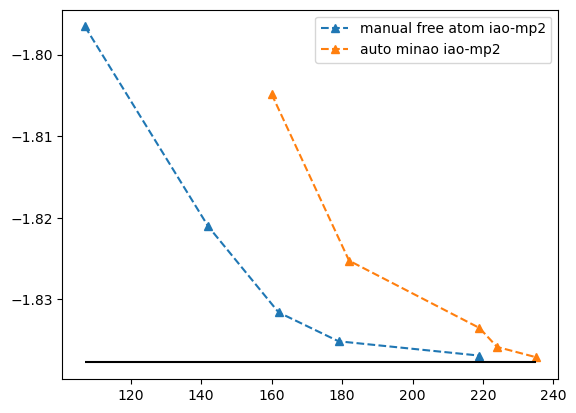

In [47]:
print(las1)
print(elnomp1)
print(las2)
print(elnomp2)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="manual free atom iao-mp2")
plt.plot(las2, elnomp2, "^--", color="C1", label="auto minao iao-mp2")
plt.hlines(emp2_ref, xmin=min(las1), xmax=max(las2), colors='k')
plt.legend()
plt.show()

In [48]:
iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='h2heavy', more_loc='pm', ref_basis='manual')

las3 = np.zeros(len(threshs))
elnomp3 = np.zeros(len(threshs))
elnocc3 = np.zeros(len(threshs))
elnoqmc3 = np.zeros(len(threshs))
elnoqmc_err3 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las3[i], elnomp3[i], elnocc3[i], elnoqmc3[i], elnoqmc_err3[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )

Spherically averaged atomic HF for {'Fe', 'H', 'O'}


******** <class 'pyscf.scf.atom_hf.AtomSphAverageRHF'> ********
method = AtomSphAverageRHF
initial guess = minao
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 50
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmppef20ya4
max_memory 20000 MB (current use 3017 MB)
atom = Fe
Set gradient conv threshold to 3.16228e-05
Initial guess from minao.
init E= -1256.92456910641
cycle= 1 E= -1255.99896402579  delta_E= 0.926  |g|=    0  |ddm|= 25.2
cycle= 2 E= -1255.09761857463  delta_E= 0.901  |g|=    0  |ddm|= 23.3
cycle= 3 E= -1260.61453893918  delta_E= -5.52  |g|=    0  |ddm|=  3.4
cycle= 4 E= -1261.57170867645  delta_E= -0.957  |g|=    0  |ddm|= 1.27
cycle= 5 E= -1261.5755539638  delta_E= -0.00385  |g|=    0  |ddm|= 0.318
cycle= 6 E= -1261.57670160295  delta_E= -0.00115 

[107. 142. 162. 179. 219.]
[-1.79655234 -1.82104512 -1.83159191 -1.835128   -1.83688261]
[160. 182. 219. 224. 235.]
[-1.80483216 -1.82525055 -1.83349476 -1.83581797 -1.83707309]
[103. 141. 165. 176. 212.]
[-1.7998011  -1.82280411 -1.8323678  -1.83527136 -1.83682202]


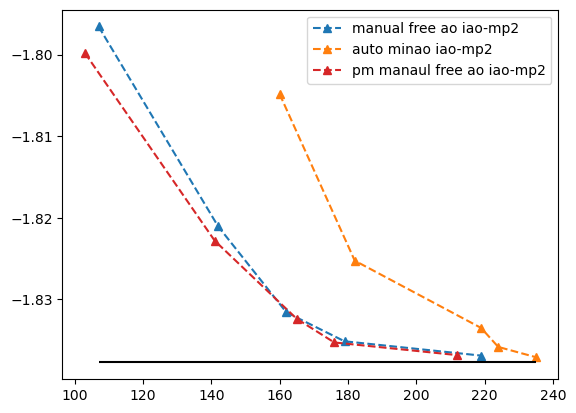

In [50]:
print(las1)
print(elnomp1)
print(las2)
print(elnomp2)
print(las3)
print(elnomp3)

from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="manual free ao iao-mp2")
plt.plot(las2, elnomp2, "^--", color="C1", label="auto minao iao-mp2")
plt.plot(las3, elnomp3, "^--", color="C3", label="pm manaul free ao iao-mp2")

plt.hlines(emp2_ref, xmin=min(las1), xmax=max(las2), colors='k')
plt.legend()
plt.show()